# Cook Data Exploration

## Imports

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Import and Combine

### Crop

In [22]:
crop = pd.read_csv("./Data/CookHandHarvest_HY1999-HY2016_P3A3_20241029(in).csv")

In [23]:
shape_before = crop.shape
print(shape_before)

(6642, 26)


In [24]:
# drop any columns that are more than 1000 missing values
crop = crop.loc[:, crop.isna().sum() <= 1000]

# Drop unnecessary "SampleID" Column
crop.drop(columns=["SampleID"], inplace=True)

In [25]:
# Drop rows with missing "Crop" or "GrainYieldAirDry" Values
crop = crop.dropna()
crop.isna().sum()

HarvestYear         0
ID2                 0
Longitude           0
Latitude            0
Crop                0
QCCoverage          0
QCFlags             0
CropExists          0
GrainYieldAirDry    0
dtype: int64

In [26]:
shape_after = crop.shape
print(shape_after) 

print(f'Dropped Column amount: {shape_before[1] - shape_after[1]}')
print(f'Dropped Row amount: {shape_before[0] - shape_after[0]}')

(6285, 9)
Dropped Column amount: 17
Dropped Row amount: 357


### Terrain

In [27]:
terrain = pd.read_csv("./Data/CookTerrainAttributes10m2_P3A1_20210119.csv")

In [32]:
terrain.head()

,ID2,FieldName,Latitude,Longitude,Elevation,AnalyticalHillshade,ConvergenceIndex,TotalCatchmentArea,TopographicWetnessIndex,LengthSlopeFactor,...,ChannelNetworkDistance,ValleyDepth,RelativeSlopePosition,Slope,Aspect,TRASP,ProfileCurvature,PlanCurvature,TangentialCurvature,AnnualGlobalSolarRadiation
0,1,CookEast,46.778729,-117.087514,781.48643,0.857087,3.197987,682.413452,5.702310,1.407364,...,2.433228,31.977112,0.070712,7.600873,195.363983,0.983775,-0.000807,-0.001175,-0.000155,1860.944336
1,2,CookEast,46.778692,-117.087065,782.43932,0.835344,-0.196646,1105.528442,6.433780,1.126312,...,2.692078,31.024231,0.079845,5.939017,198.724243,0.990349,-0.001025,-0.004596,-0.000476,1833.973389
2,3,CookEast,46.778791,-117.086678,784.93625,0.859389,1.008778,689.028320,5.602043,1.622139,...,4.639526,28.526917,0.139886,8.471982,198.494370,0.989953,-0.001278,0.009172,0.001351,1871.270264
3,4,CookEast,46.778761,-117.086260,786.42902,0.876073,-0.155071,865.019226,5.865278,1.622096,...,5.796997,27.032532,0.176579,8.178418,188.564774,0.965416,-0.000061,0.024965,0.003551,1873.524658
4,5,CookEast,46.778666,-117.085842,786.51237,0.843491,0.770311,563.946228,5.538609,1.308802,...,5.668457,26.945679,0.173804,7.400980,201.473892,0.994474,-0.001019,0.025449,0.003278,1853.676514


In [30]:
shape_before = terrain.shape
print(shape_before)

(619, 21)


In [31]:
terrain.isna().sum()

ID2                           0
FieldName                     0
Latitude                      0
Longitude                     0
Elevation                     0
AnalyticalHillshade           0
ConvergenceIndex              0
TotalCatchmentArea            0
TopographicWetnessIndex       0
LengthSlopeFactor             0
ChannelNetworkBaseLevel       0
ChannelNetworkDistance        0
ValleyDepth                   0
RelativeSlopePosition         0
Slope                         0
Aspect                        0
TRASP                         0
ProfileCurvature              0
PlanCurvature                 0
TangentialCurvature           0
AnnualGlobalSolarRadiation    0
dtype: int64

In [33]:
shape_after = terrain.shape
print(shape_after) 

print(f'Dropped Column amount: {shape_before[1] - shape_after[1]}')
print(f'Dropped Row amount: {shape_before[0] - shape_after[0]}')

(619, 21)
Dropped Column amount: 0
Dropped Row amount: 0


### Combine

In [75]:
print(f"crop['ID2'].nunique(): {crop['ID2'].nunique()}")
print(f"terrain['ID2'].nunique(): {terrain['ID2'].nunique()}")

crop['ID2'].nunique(): 369
terrain['ID2'].nunique(): 619


`crop` only contains data from *Cook East* location but `terrain` contains data from *Cook East* and *Cook West*

In [74]:
print(f"terrain['Longitude'].iloc[0]: {terrain['Longitude'].iloc[0]}")
print(f"crop['Longitude'].iloc[0]: {crop['Longitude'].iloc[0]}")

terrain['Longitude'].iloc[0]: -117.08751399999728
crop['Longitude'].iloc[0]: -117.087514


In [96]:
# Combine "crop" and "terrain" dataframes on "ID2" column
combined = pd.merge(crop, terrain, on=["ID2"], how="inner")

**Note:** I tried to merge based off Longitude and Latitude but the "terrain" dataframes values are more precise so the values do not match (see cell above). This is why we merge based on "ID2" primarily. Later we should return to this and ensure that the ID2's Longitude and Latitude match. 

In [46]:
combined.shape

(6285, 27)

In [97]:
combined.isna().sum()

HarvestYear                   0
ID2                           0
Longitude_x                   0
Latitude_x                    0
Crop                          0
QCCoverage                    0
QCFlags                       0
CropExists                    0
GrainYieldAirDry              0
FieldName                     0
Latitude_y                    0
Longitude_y                   0
Elevation                     0
AnalyticalHillshade           0
ConvergenceIndex              0
TotalCatchmentArea            0
TopographicWetnessIndex       0
LengthSlopeFactor             0
ChannelNetworkBaseLevel       0
ChannelNetworkDistance        0
ValleyDepth                   0
RelativeSlopePosition         0
Slope                         0
Aspect                        0
TRASP                         0
ProfileCurvature              0
PlanCurvature                 0
TangentialCurvature           0
AnnualGlobalSolarRadiation    0
dtype: int64

## Data Exploration

<!-- Exploring the crop and terrain data `combined` Dataframe.  -->

In [98]:
# Drop "QCCoverage" column becauuse it is NaN

combined.drop(columns=["QCCoverage"], inplace=True)

In [99]:
# Remove the following to simplify the dataset
columns_to_remove = [
    "ID2",
    "HarvestYear",
    "Longitude_x",
    "Latitude_x",
    "Longitude_y",
    "Latitude_y",
    "FieldName",
    
]
combined.drop(columns=columns_to_remove, inplace=True)

In [100]:
print(combined.columns.tolist())

['Crop', 'QCFlags', 'CropExists', 'GrainYieldAirDry', 'Elevation', 'AnalyticalHillshade', 'ConvergenceIndex', 'TotalCatchmentArea', 'TopographicWetnessIndex', 'LengthSlopeFactor', 'ChannelNetworkBaseLevel', 'ChannelNetworkDistance', 'ValleyDepth', 'RelativeSlopePosition', 'Slope', 'Aspect', 'TRASP', 'ProfileCurvature', 'PlanCurvature', 'TangentialCurvature', 'AnnualGlobalSolarRadiation']


In [101]:
combined.shape

(6285, 21)

In [83]:
combined["GrainYieldAirDry"].max()

883.2212021

In [ ]:
combined["GrainYieldAirDry"].min()


0.0

In [85]:

print(combined.columns.tolist())


['HarvestYear', 'ID2', 'Longitude_x', 'Latitude_x', 'Crop', 'QCCoverage', 'QCFlags', 'CropExists', 'GrainYieldAirDry', 'FieldName', 'Latitude_y', 'Longitude_y', 'Elevation', 'AnalyticalHillshade', 'ConvergenceIndex', 'TotalCatchmentArea', 'TopographicWetnessIndex', 'LengthSlopeFactor', 'ChannelNetworkBaseLevel', 'ChannelNetworkDistance', 'ValleyDepth', 'RelativeSlopePosition', 'Slope', 'Aspect', 'TRASP', 'ProfileCurvature', 'PlanCurvature', 'TangentialCurvature', 'AnnualGlobalSolarRadiation']


In [ ]:
sns.pairplot(combined)
plt.show()

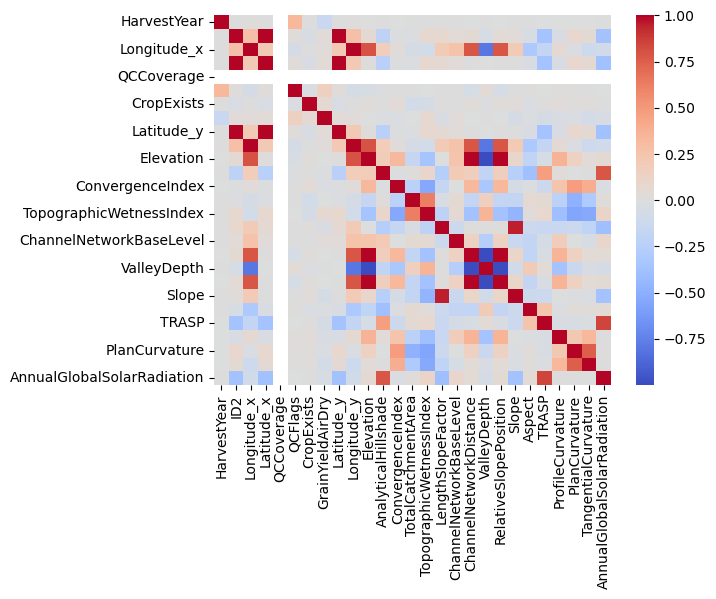

In [90]:
corr = combined.select_dtypes(include="number").corr()

sns.heatmap(corr, cmap="coolwarm")
plt.show()


In [91]:
corr

,HarvestYear,ID2,Longitude_x,Latitude_x,QCCoverage,QCFlags,CropExists,GrainYieldAirDry,Latitude_y,Longitude_y,...,ChannelNetworkDistance,ValleyDepth,RelativeSlopePosition,Slope,Aspect,TRASP,ProfileCurvature,PlanCurvature,TangentialCurvature,AnnualGlobalSolarRadiation
HarvestYear,1.000000,0.004024,0.008752,0.003873,NaN,0.334821,0.002683,-0.142657,0.003888,0.008750,...,-0.000934,0.000152,-0.001069,0.001199,0.001860,-0.001099,-0.004553,-0.005098,-0.006059,0.000780
ID2,0.004024,1.000000,0.276592,0.996424,NaN,0.018014,-0.033526,0.038284,0.996424,0.276593,...,0.052012,-0.052454,0.046619,0.023841,-0.050765,-0.366747,-0.035493,0.080850,0.052663,-0.373653
Longitude_x,0.008752,0.276592,1.000000,0.218199,NaN,-0.059508,0.004623,0.026640,0.218205,1.000000,...,0.787018,-0.799212,0.785629,0.198456,-0.316383,-0.175597,0.062250,-0.030023,-0.109852,-0.092631
Latitude_x,0.003873,0.996424,0.218199,1.000000,NaN,0.022649,-0.034982,0.037502,1.000000,0.218200,...,0.006109,-0.006575,0.000809,0.007019,-0.031693,-0.364895,-0.031744,0.084783,0.061868,-0.375929
QCCoverage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
QCFlags,0.334821,0.018014,-0.059508,0.022649,NaN,1.000000,-0.030086,0.154197,0.022660,-0.059510,...,-0.047448,0.046642,-0.048000,0.003604,0.008620,-0.007363,0.013866,0.010969,0.005248,-0.007526
CropExists,0.002683,-0.033526,0.004623,-0.034982,NaN,-0.030086,1.000000,0.055618,-0.034982,0.004623,...,0.021377,-0.021294,0.021574,0.030111,-0.026064,0.012918,0.025985,0.013233,0.016333,0.002479
GrainYieldAirDry,-0.142657,0.038284,0.026640,0.037502,NaN,0.154197,0.055618,1.000000,0.037496,0.026644,...,-0.004213,0.000104,-0.003009,-0.060656,-0.017143,-0.057638,-0.035612,-0.030201,-0.071583,-0.043800
Latitude_y,0.003888,0.996424,0.218205,1.000000,NaN,0.022660,-0.034982,0.037496,1.000000,0.218206,...,0.006115,-0.006581,0.000815,0.007029,-0.031704,-0.364891,-0.031741,0.084777,0.061864,-0.375927
Longitude_y,0.008750,0.276593,1.000000,0.218200,NaN,-0.059510,0.004623,0.026644,0.218206,1.000000,...,0.787018,-0.799212,0.785629,0.198459,-0.316382,-0.175598,0.062251,-0.030019,-0.109846,-0.092634


## Data Processing

### Encoding Categorical Values

### Scaling